In [1]:
%load_ext autoreload
%autoreload 2
import os,csv,re,time

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from scipy.sparse import issparse
import scanpy as sc

import cv2
from IPython.display import Image
import sys
sys.path.append('/home/lixiangyu/zjx/spark/benchmark/methods')
import result_reader

import torch
import torch.nn as nn
from torchvision import models, transforms

sys.path.append('/home/lixiangyu/zjx/spark/datasets')
import dataset_reader

sys.path.append("/home/lixiangyu/zjx/benchmark/batch_removal_output/")
import warnings

sys.path.append('/home/lixiangyu/zjx/spark/function/super_resolution/TESLA/MAGIC-main/python/magic')
import magic

warnings.filterwarnings("ignore")
from IPython.display import Image
import anndata as ad

import scipy.sparse as sp

In [2]:


def scale_contour(cnt, scale):
    """轮廓缩放（保留）"""
    M = cv2.moments(cnt)
    if M['m00'] == 0:
        return cnt
    cx = int(M['m10']/M['m00'])
    cy = int(M['m01']/M['m00'])
    cnt_norm = cnt - [cx, cy]
    cnt_scaled = cnt_norm * scale
    cnt_scaled = cnt_scaled + [cx, cy]
    cnt_scaled = cnt_scaled.astype(np.int32)
    return cnt_scaled

def he_tissue_segmentation_with_internal_bg(
    img,
    blur_ksize=5,          
    a_channel_thresh=None,  
    min_area=10000,        # 最小组织连通域面积（过滤小噪点）
    min_hole_area=5000,     # 最小内部孔洞面积（过滤微小孔隙）
    morph_ksize=15,        
    smooth_eps=0.001       
):
    """
    纯HE图像分割：识别外部背景 + 内部背景（孔洞/空腔）
    返回：
        - outer_cnt：组织外轮廓（不含内部孔洞）
        - tissue_mask：纯净组织掩码（排除外部+内部背景）
        - hole_cnts：内部背景（孔洞）的轮廓列表
    """
    # ---------------------- 1. 预处理：去噪 + 颜色空间转换 ----------------------
    img_blur = cv2.GaussianBlur(img, (blur_ksize, blur_ksize), 0)
    lab = cv2.cvtColor(img_blur, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    hsv = cv2.cvtColor(img_blur, cv2.COLOR_BGR2HSV)
    _, s, _ = cv2.split(hsv)

    # ---------------------- 2. 双通道融合分割 ----------------------
    if a_channel_thresh is None:
        _, a_mask = cv2.threshold(a, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    else:
        _, a_mask = cv2.threshold(a, a_channel_thresh, 255, cv2.THRESH_BINARY)
    _, s_mask = cv2.threshold(s, 20, 255, cv2.THRESH_BINARY)
    mask = cv2.bitwise_and(a_mask, s_mask)

    # ---------------------- 3. 形态学优化：克制操作（不填充内部孔洞） ----------------------
    # 仅1次闭运算（填充极小孔隙，保留有意义的内部孔洞）
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_ksize, morph_ksize))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_close, iterations=1)
    # 开运算：去除背景小噪点
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_ksize//2, morph_ksize//2))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)

    # ---------------------- 4. 提取内外轮廓（关键：RETR_CCOMP） ----------------------
    # RETR_CCOMP：检索所有轮廓，并分成两层（外轮廓=层级0，内轮廓=层级1）
    contours, hierarchy = cv2.findContours(
        mask, 
        cv2.RETR_CCOMP,       # 核心：支持内外轮廓分层
        cv2.CHAIN_APPROX_SIMPLE
    )
    if not contours:
        raise RuntimeError("未检测到任何组织区域！")
    
    # 解析层级：hierarchy = [Next, Previous, First_Child, Parent]
    hierarchy = hierarchy[0]  # 取出层级数组

    # ---------------------- 5. 筛选外轮廓（组织主体） + 内轮廓（内部孔洞） ----------------------
    outer_contours = []    # 组织外轮廓（层级0，无父轮廓）
    hole_contours = []     # 内部孔洞轮廓（层级1，有父轮廓）
    
    for i, (cnt, h) in enumerate(zip(contours, hierarchy)):
        cnt_area = cv2.contourArea(cnt)
        # 外轮廓：层级0（Parent=-1）+ 面积≥min_area
        if h[3] == -1 and cnt_area >= min_area:
            outer_contours.append(cnt)
        # 内轮廓：层级1（有父轮廓）+ 面积≥min_hole_area（过滤微小孔隙）
        elif h[3] != -1 and cnt_area >= min_hole_area:
            hole_contours.append(cnt)

    # 取最大的外轮廓（组织主体）
    if not outer_contours:
        raise RuntimeError("未检测到有效组织外轮廓！")
    outer_contour_areas = [cv2.contourArea(c) for c in outer_contours]
    max_outer_idx = np.argmax(outer_contour_areas)
    main_outer_cnt = outer_contours[max_outer_idx]

    # ---------------------- 6. 生成纯净组织掩码（扣除内部孔洞） ----------------------
    # 第一步：绘制外轮廓掩码（包含内部孔洞）
    outer_mask = np.zeros_like(mask)
    cv2.drawContours(outer_mask, [main_outer_cnt], -1, 255, -1)
    # 第二步：绘制内部孔洞掩码
    hole_mask = np.zeros_like(mask)
    cv2.drawContours(hole_mask, hole_contours, -1, 255, -1)
    # 第三步：扣除内部孔洞 → 纯净组织掩码
    tissue_mask = cv2.bitwise_and(outer_mask, cv2.bitwise_not(hole_mask))

    # ---------------------- 7. 轮廓平滑 ----------------------
    # 外轮廓平滑
    outer_perimeter = cv2.arcLength(main_outer_cnt, closed=True)
    smooth_outer_cnt = cv2.approxPolyDP(
        main_outer_cnt, 
        epsilon=smooth_eps * outer_perimeter,
        closed=True
    )
    # 内部孔洞轮廓平滑
    smooth_hole_cnts = []
    for hole_cnt in hole_contours:
        hole_perimeter = cv2.arcLength(hole_cnt, closed=True)
        smooth_hole = cv2.approxPolyDP(
            hole_cnt,
            epsilon=smooth_eps * hole_perimeter,
            closed=True
        )
        smooth_hole_cnts.append(smooth_hole)

    return smooth_outer_cnt, tissue_mask, smooth_hole_cnts



# ---------------------- 补充依赖函数（scale_contour必须存在） ----------------------
def scale_contour(cnt, scale):
    M = cv2.moments(cnt)
    if M['m00'] == 0:  # 避免除以0
        return cnt
    cx = int(M['m10']/M['m00'])
    cy = int(M['m01']/M['m00'])
    cnt_norm = cnt - [cx, cy]
    cnt_scaled = cnt_norm * scale
    cnt_scaled = cnt_scaled + [cx, cy]
    cnt_scaled = cnt_scaled.astype(np.int32)
    return cnt_scaled

# ---------------------- 新增：定义Embedding提取函数 ---------------------- #
def load_he_embedding_model(pretrained=True):
    """加载预训练ResNet50，提取HE图像块的Embedding（输出512维）"""
    model = models.resnet50(pretrained=pretrained)
    # 移除最后全连接层，保留特征提取部分
    model = nn.Sequential(*list(model.children())[:-1])
    model.eval()  # 推理模式
    return model

def extract_he_embedding_batch(
    x_pixel,
    y_pixel,
    image,
    beta,
    model,
    device="cuda",
    batch_size=64
):
    """
    向量化 + batch 的 HE embedding 提取
    返回 shape = (n_spots, 512)
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])

    patches = []
    coords = list(zip(x_pixel, y_pixel))

    # --------- 1. 先在 CPU 端裁 patch（修正坐标逻辑） ---------
    for x, y in coords:
        x, y = int(x), int(y)
        # 修正：x是行（img.shape[0]），y是列（img.shape[1]）
        row1 = max(0, x - beta // 2)
        row2 = min(image.shape[0], x + beta // 2)
        col1 = max(0, y - beta // 2)
        col2 = min(image.shape[1], y + beta // 2)

        patch = image[row1:row2, col1:col2, :]  # CV2：行在前，列在后
        patch = cv2.resize(patch, (beta, beta))  # 保证尺寸一致
        patch = transform(patch)                 # [3, H, W]
        patches.append(patch)

    patches = torch.stack(patches)  # [N, 3, H, W]

    # --------- 2. batch forward ---------
    embeddings = []

    model.eval()
    with torch.no_grad():
        for i in range(0, patches.shape[0], batch_size):
            batch = patches[i:i+batch_size].to(device)
            emb = model(batch).squeeze(-1).squeeze(-1)  # [B, 512]
            embeddings.append(emb.cpu())

    embeddings = torch.cat(embeddings, dim=0).numpy()

    # --------- 3. L2 normalize ---------
    embeddings /= np.linalg.norm(embeddings, axis=1, keepdims=True)

    return embeddings

# ---------------------- 修改原imputation函数（核心：加入hole_cnts，筛选有效组织） ---------------------- #
def imputation(img, raw, cnt, hole_cnts, genes, shape="None", res=50, s=1, k=2, num_nbs=10):
    print('imputating')
    # ---------------------- 关键修改1：生成纯净组织掩码（排除外部背景+内部孔洞） ----------------------
    # 1. 初始化全0掩码（uint8类型，避免类型错误）
    tissue_mask = np.zeros(img.shape[:2], dtype=np.uint8)
    # 2. 绘制组织外轮廓（填充为255，代表组织区域）
    cv2.drawContours(tissue_mask, [cnt], -1, 255, thickness=-1)
    # 3. 扣除内部孔洞（将孔洞区域置为0）
    cv2.drawContours(tissue_mask, hole_cnts, -1, 0, thickness=-1)
    
    # 4. 可选：轻微放大组织掩码（避免边缘丢失，保持原逻辑的1.05倍）
    cnt_enlarged = scale_contour(cnt, 1.05)
    tissue_mask_enlarged = np.zeros(img.shape[:2], dtype=np.uint8)
    cv2.drawContours(tissue_mask_enlarged, [cnt_enlarged], -1, 255, thickness=-1)
    # 放大后仍需扣除内部孔洞
    cv2.drawContours(tissue_mask_enlarged, hole_cnts, -1, 0, thickness=-1)

    # ---------------------- 关键修改2：生成sudo点并筛选（仅保留有效组织区域） ----------------------
    x_max, y_max = img.shape[0], img.shape[1]
    # 按res步长生成网格点
    x_list = list(range(int(res), x_max, int(res)))
    y_list = list(range(int(res), y_max, int(res)))
    x = np.repeat(x_list, len(y_list)).tolist()
    y = y_list * len(x_list)
    sudo = pd.DataFrame({"x": x, "y": y})
    
    # 筛选：仅保留落在放大后组织掩码内的点（值为255代表有效组织）
    # 注意：sudo.x是行（tissue_mask的第一维），sudo.y是列（tissue_mask的第二维）
    valid_idx = [
        i for i in sudo.index 
        if (0 <= sudo.x[i] < tissue_mask_enlarged.shape[0]) and 
           (0 <= sudo.y[i] < tissue_mask_enlarged.shape[1]) and 
           (tissue_mask_enlarged[sudo.x[i], sudo.y[i]] == 255)
    ]
    sudo = sudo.loc[valid_idx].reset_index(drop=True)
    print(f"有效组织区域内的sudo点数量：{len(sudo)}")
    
    if len(sudo) == 0:
        raise RuntimeError("有效组织区域内无sudo点！请检查res或掩码生成逻辑")
    
    b = 64

    # ---------------------- 关键修改1：加载Embedding模型 + 提取sudo点Embedding ---------------------- #
    device = "cuda" if torch.cuda.is_available() else "cpu"
    embedding_model = load_he_embedding_model().to(device)
    # 提取sudo点的HE Embedding
    sudo_embeddings = extract_he_embedding_batch(
        x_pixel=sudo.x.tolist(),
        y_pixel=sudo.y.tolist(),
        image=img,
        beta=b,
        model=embedding_model,
        device=device,
        batch_size=64
    )
    # 归一化Embedding（L2归一化）
    sudo_embeddings = sudo_embeddings / np.linalg.norm(sudo_embeddings, axis=1, keepdims=True)
    sudo["embedding"] = list(sudo_embeddings)  # 存储Embedding（n×512）

    # ---------------------- 关键修改2：提取已知spot的Embedding ---------------------- #
    known_adata = raw[:, raw.var.index.isin(genes)]
    known_adata.obs["x"] = known_adata.obs["pixel_col"]  # 修正：x对应行（pixel_row）
    known_adata.obs["y"] = known_adata.obs["pixel_row"]  # 修正：y对应列（pixel_col）
    # 提取已知spot的HE Embedding（过滤掉已知spot中不在组织区域的点）
    known_valid_idx = [
        i for i in known_adata.obs.index
        if (0 <= known_adata.obs["x"][i] < tissue_mask.shape[0]) and 
           (0 <= known_adata.obs["y"][i] < tissue_mask.shape[1]) and 
           (tissue_mask[int(known_adata.obs["x"][i]), int(known_adata.obs["y"][i])] == 255)
    ]
    known_adata = known_adata[known_valid_idx].copy()
    print(f"有效组织区域内的已知spot数量：{len(known_adata)}")
    
    if len(known_adata) == 0:
        raise RuntimeError("有效组织区域内无已知spot！无法进行补全")
    
    known_embeddings = extract_he_embedding_batch(
        x_pixel=known_adata.obs["x"].astype(int).tolist(), 
        y_pixel=known_adata.obs["y"].astype(int).tolist(), 
        image=img, beta=b, model=embedding_model, device=device, batch_size=64
    )
    known_embeddings = known_embeddings / np.linalg.norm(known_embeddings, axis=1, keepdims=True)
    known_adata.obs["embedding"] = list(known_embeddings)  # 存储Embedding

    # ---------------------- 关键修改3：重构距离计算（空间距离 + Embedding余弦距离） ---------------------- #
    start_time = time.time()
    dis = np.zeros((sudo.shape[0], known_adata.shape[0]))
    # 提取x/y坐标（空间特征）
    x_sudo, y_sudo = sudo["x"].values, sudo["y"].values
    x_known, y_known = known_adata.obs["x"].values, known_adata.obs["y"].values
    # 提取Embedding（高维特征）
    sudo_emb = np.array(sudo["embedding"].tolist())
    known_emb = np.array(known_adata.obs["embedding"].tolist())

    print("Total number of sudo points: ", sudo.shape[0])
    # 优化：用向量化计算替代双重循环
    for i in range(sudo.shape[0]):
        if i % 1000 == 0:
            print("Calculating spot", i)
        # 1. 计算空间欧式距离（x/y）
        spatial_dis = np.sqrt((x_sudo[i] - x_known)**2 + (y_sudo[i] - y_known)**2)
        # 2. 计算Embedding余弦距离（1 - 余弦相似度，距离越小越相似）
        cos_dis = 1 - np.dot(sudo_emb[i], known_emb.T)
        # 3. 加权融合空间距离和Embedding距离（可调整权重α）
        α = 0.6  # 空间距离权重，Embedding权重=1-α
        dis[i] = α * (spatial_dis / np.max(spatial_dis)) + (1-α) * cos_dis  # 归一化后加权

    print("--- %s seconds ---" % (time.time() - start_time))
    dis = pd.DataFrame(dis, index=sudo.index, columns=known_adata.obs.index)

    # ---------------------- 原填充逻辑（无需修改） ---------------------- #
    sudo_adata = sc.AnnData(np.zeros((sudo.shape[0], len(genes))))
    sudo_adata.obs = sudo
    sudo_adata.var = known_adata.var
    for i in range(sudo_adata.shape[0]):
        if i % 1000 == 0:
            print("Imputing spot", i)
        dis_tmp = dis.iloc[i, :].sort_values()
        nbs = dis_tmp[0:num_nbs]
        dis_tmp = (nbs.to_numpy() + 0.1) / np.min(nbs.to_numpy() + 0.1)
        if isinstance(k, int):
            weights = ((1/(dis_tmp**k)) / ((1/(dis_tmp**k)).sum()))
        else:
            weights = np.exp(-dis_tmp) / np.sum(np.exp(-dis_tmp))
        row_index = [known_adata.obs.index.get_loc(i) for i in nbs.index]
        sudo_adata.X[i, :] = np.dot(weights, known_adata.X[row_index, :])
    
    # 额外：给sudo_adata添加组织掩码标记（方便后续验证）
    sudo_adata.obs["in_tissue"] = True
    sudo_adata.obsm["spatial"] = sudo[["y", "x"]].values  # 符合scanpy spatial格式（col, row）
    
    return sudo_adata




**************** start E11.0-S1-RNA **********************
Calculating MAGIC...
  Running MAGIC on 1263 cells and 31433 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 8.39 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.20 seconds.
    Calculating affinities...
    Calculated affinities in 0.28 seconds.
  Calculated graph and diffusion operator in 8.88 seconds.
  Running MAGIC with `solver='exact'` on 31433-dimensional data may take a long time. Consider denoising specific genes with `genes=<list-like>` or using `solver='approximate'`.
  Calculating imputation...
  Calculated imputation in 0.82 seconds.
Calculated MAGIC in 9.76 seconds.


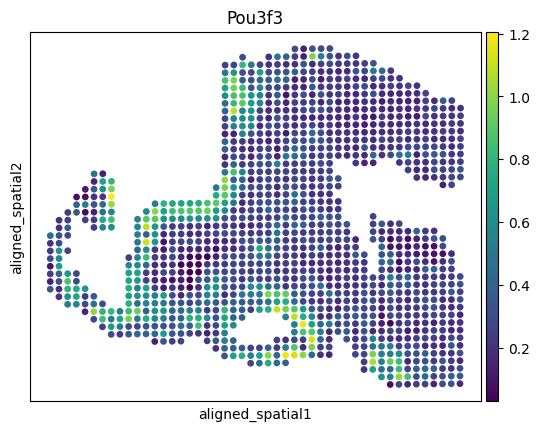

imputating
有效组织区域内的sudo点数量：10781
有效组织区域内的已知spot数量：1064
Total number of sudo points:  10781
Calculating spot 0
Calculating spot 1000
Calculating spot 2000
Calculating spot 3000
Calculating spot 4000
Calculating spot 5000
Calculating spot 6000
Calculating spot 7000
Calculating spot 8000
Calculating spot 9000
Calculating spot 10000
--- 1.6433393955230713 seconds ---
Imputing spot 0
Imputing spot 1000
Imputing spot 2000
Imputing spot 3000
Imputing spot 4000
Imputing spot 5000
Imputing spot 6000
Imputing spot 7000
Imputing spot 8000
Imputing spot 9000
Imputing spot 10000
最终增强后的数据维度：(10781, 31433)
增强后数据的空间坐标范围：
x（行）：10 ~ 1380
y（列）：20 ~ 1450
**************** start E11.0-S2-genescore **********************
Calculating MAGIC...
  Running MAGIC on 1353 cells and 24333 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 8.96 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.22 seconds.
    Calculating affinities...
    Calculated a

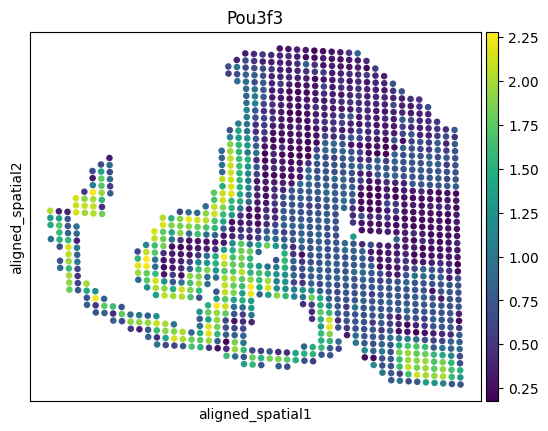

imputating
有效组织区域内的sudo点数量：10781
有效组织区域内的已知spot数量：1125
Total number of sudo points:  10781
Calculating spot 0
Calculating spot 1000
Calculating spot 2000
Calculating spot 3000
Calculating spot 4000
Calculating spot 5000
Calculating spot 6000
Calculating spot 7000
Calculating spot 8000
Calculating spot 9000
Calculating spot 10000
--- 10.328419923782349 seconds ---
Imputing spot 0
Imputing spot 1000
Imputing spot 2000
Imputing spot 3000
Imputing spot 4000
Imputing spot 5000
Imputing spot 6000
Imputing spot 7000
Imputing spot 8000
Imputing spot 9000
Imputing spot 10000
最终增强后的数据维度：(10781, 24333)
增强后数据的空间坐标范围：
x（行）：10 ~ 1380
y（列）：20 ~ 1450


In [3]:
dataset_id='MISAR2'
sample_id_ref='E11.0-S1-HE'
sample_id_src_list=dataset_reader.get_dataset_info('my')[dataset_id]['src']

enhanced_adata_list=[]
save_dir=f'./results/{dataset_id}/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)



for sample_id_src in sample_id_src_list:
    print(f"**************** start {sample_id_src} **********************")
    result=result_reader.read_result('my','MISAR2')
    result=result[result.obs['batch']==sample_id_src]
    result.var["genename"]=result.var.index.astype("str")

    counts=dataset_reader.read_dataset('MISAR',sample_id_src)
    counts.obsm['aligned_spatial']=result.obsm['aligned_spatial']
    
    X = counts.X
    magic_operator = magic.MAGIC()
    counts_denoise=counts.copy()
    counts_denoise.X = magic_operator.fit_transform(counts.X)
    counts=counts_denoise.copy()
    sc.pl.embedding(counts,color='Pou3f3',basis='aligned_spatial')
    img_path = f'/home/lixiangyu/zjx/spark/img/{dataset_id}-{sample_id_ref}/RGB.png'
    img = cv2.imread(img_path)

    resize_factor=1000/np.min(img.shape[0:2])
    resize_width=int(img.shape[1]*resize_factor)
    resize_height=int(img.shape[0]*resize_factor)
    counts.var_names_make_unique()
    counts.raw=counts
    # sc.pp.log1p(counts) # impute on log scale
    if issparse(counts.X):counts.X=counts.X.todense()

    counts.obs['pixel_col']=counts.obsm['aligned_spatial'][:,1]
    counts.obs['pixel_row']=counts.obsm['aligned_spatial'][:,0]
    counts.obs['array_x']=counts.obs['array_row'].copy()
    counts.obs['array_y']=counts.obs['array_col'].copy()

    # ========== 新增：筛选counts，移除超出HE图像范围的spots ==========
    # 获取HE图像的像素边界（height: 行范围，width: 列范围）
    img_height = img.shape[0]  # 对应pixel_x的有效范围
    img_width = img.shape[1]   # 对应pixel_y的有效范围

    valid_mask = (
        (counts.obs['pixel_row'] >= 0) & 
        (counts.obs['pixel_row'] <= img_height) & 
        (counts.obs['pixel_col'] >= 0) & 
        (counts.obs['pixel_col'] <= img_width)
    )

    counts = counts[valid_mask].copy()
    
    
    # 提取外轮廓、纯净组织掩码、内部孔洞轮廓
    cnt, tissue_mask, hole_cnts = he_tissue_segmentation_with_internal_bg(
        img,
        blur_ksize=5,
        a_channel_thresh=None,
        min_area=10000,
        min_hole_area=5000,  # 识别面积≥5000的内部孔洞
        morph_ksize=25,
        smooth_eps=0.0005
    )


    # ---------------------- 可视化验证（关键：标注内部背景） ----------------------
    img_with_contours = img.copy()
    # 绘制组织外轮廓（绿色）
    cv2.drawContours(img_with_contours, [cnt], -1, (0, 255, 0), thickness=5)
    # 绘制内部孔洞轮廓（红色）
    cv2.drawContours(img_with_contours, hole_cnts, -1, (0, 0, 255), thickness=3)

    # 调整大小显示
    resize_factor=1000/np.min(img.shape[0:2])
    resize_width=int(img.shape[1]*resize_factor)
    resize_height=int(img.shape[0]*resize_factor)
    img_with_contours = cv2.resize(img_with_contours, (resize_width, resize_height))

    # 保存结果
    cv2.imwrite(f'{save_dir}/HE_{sample_id_ref}.jpg', img_with_contours)
    Image(filename=f'{save_dir}/HE_{sample_id_ref}.jpg')

    # res=10  # 超分辨率分辨率
    res=10
    # 调用修改后的imputation函数（新增hole_cnts参数）
    enhanced_exp_adata = imputation(
        img=img, 
        raw=counts, 
        cnt=cnt,          # 组织外轮廓
        hole_cnts=hole_cnts,  # 内部孔洞轮廓（核心：用于扣除内部背景）
        genes=counts.var.index.tolist(), 
        shape="None", 
        res=res, 
        s=1, 
        k=4, 
        num_nbs=4
    )

    # 验证：输出有效组织区域的结果信息
    print(f"最终增强后的数据维度：{enhanced_exp_adata.shape}")
    print(f"增强后数据的空间坐标范围：")
    print(f"x（行）：{enhanced_exp_adata.obsm['spatial'][:,1].min()} ~ {enhanced_exp_adata.obsm['spatial'][:,1].max()}")
    print(f"y（列）：{enhanced_exp_adata.obsm['spatial'][:,0].min()} ~ {enhanced_exp_adata.obsm['spatial'][:,0].max()}")

    enhanced_exp_adata.obsm['spatial']=enhanced_exp_adata.obs[['y','x']].values
    enhanced_exp_adata.obs['col']=enhanced_exp_adata.obs['x']
    enhanced_exp_adata.obs['row']=enhanced_exp_adata.obs['y']
    enhanced_exp_adata.obs_names=enhanced_exp_adata.obs['x'].astype(str)+'_'+enhanced_exp_adata.obs['y'].astype(str)
    embedding_matrix = np.vstack(enhanced_exp_adata.obs['embedding'].values)
    enhanced_exp_adata.obsm['HE_embedding'] = embedding_matrix
    del enhanced_exp_adata.obs['embedding']
    
    # if not sp.issparse(enhanced_exp_adata.X):
    #     enhanced_exp_adata.X = sp.csr_matrix(enhanced_exp_adata.X, dtype=np.float64)
    # print("已将 enhanced_exp_adata.X 转换为CSR稀疏矩阵")
    enhanced_exp_adata.write(f"{save_dir}/{sample_id_src}.h5ad")
    enhanced_adata_list.append(enhanced_exp_adata)
    


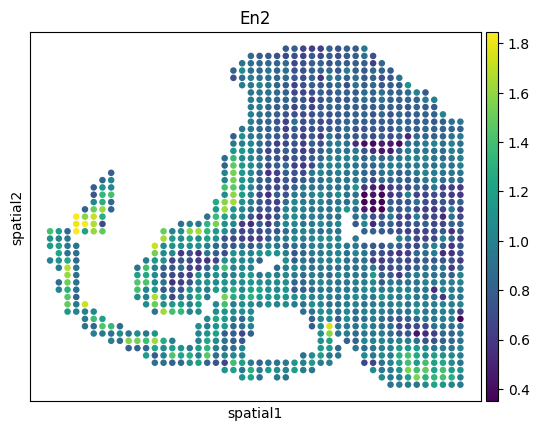

In [4]:
sc.pl.embedding(counts,color='En2',basis='spatial')

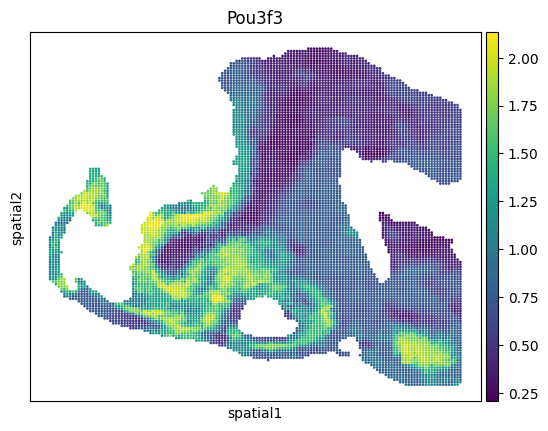

In [5]:
sc.pl.embedding(enhanced_exp_adata,color='Pou3f3',size=15,basis='spatial')